![alt text](Capture.png "Title")

In [3]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# Read data from file
def read_instance(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
        n, m = map(int, lines[0].split())  # number of jobs and machines
        processing_times = np.zeros((n, m), dtype=int)
        for i in range(n):
            data = list(map(int, lines[i+1].split()))
            for j in range(0, len(data), 2):
                machine = data[j]
                time = data[j+1]
                processing_times[i][machine] = time
    return n, m, processing_times

# Load the instance
filename = 'C:/Users/udip49yc/Python/VFR10_5_1_Gap.txt'
n, m, p = read_instance(filename)

# Big M value (sufficiently large)
M = sum(p.flatten())

# Model
model = gp.Model("PFSSP")

# Variables
C = model.addVars(n, m, vtype=GRB.CONTINUOUS, name="C")
z = model.addVars(n, n, vtype=GRB.BINARY, name="z")
C_max = model.addVar(vtype=GRB.CONTINUOUS, name="C_max")

# Objective: Minimize makespan
model.setObjective(C_max, GRB.MINIMIZE)

# Constraints

# Each job starts on first machine after its processing time
for i in range(n):
    model.addConstr(C[i, 0] >= p[i][0])

# Flow constraints (machine sequence within job)
for i in range(n):
    for k in range(m - 1):
        model.addConstr(C[i, k + 1] >= C[i, k] + p[i][k + 1])

# Job order constraints on each machine
for i in range(n):
    for j in range(n):
        if i != j:
            for k in range(m):
                model.addConstr(C[i, k] >= C[j, k] + p[i][k] - M * (1 - z[i, j]))
                model.addConstr(C[j, k] >= C[i, k] + p[j][k] - M * z[i, j])

# Eliminate self-precedence
for i in range(n):
    model.addConstr(z[i, i] == 0)

# Makespan definition
for i in range(n):
    model.addConstr(C_max >= C[i, m - 1])

# Optimize
model.optimize()

# Print results
print(f"\nOptimal Makespan: {C_max.X}")
for i in range(n):
    for k in range(m):
        print(f"C[{i},{k}] = {C[i,k].X:.2f}")

Set parameter Username
Set parameter LicenseID to value 2583787
Academic license - for non-commercial use only - expires 2025-11-14
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) Ultra 5 125U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 970 rows, 151 columns and 2820 nonzeros
Model fingerprint: 0x50b8f246
Variable types: 51 continuous, 100 integer (100 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [5e+00, 2e+03]
Presolve removed 20 rows and 10 columns
Presolve time: 0.01s
Presolved: 950 rows, 141 columns, 2800 nonzeros
Variable types: 51 continuous, 90 integer (90 binary)
Found heuristic solution: objective 756.0000000
Found heuristic solution: objective 744.0000000

Root relaxation: objective 4.650000e+02, 48 iterations, 0.00 s

In [5]:
print(M)

2052


| Label                  | Formula                   | M Value (from your output) | Interpretation                                            |
| ---------------------- | ------------------------- | -------------------------- | --------------------------------------------------------- |
| `sum(p.flatten())`     | `∑∑ p[i][k]`              | 2052                       | **Total processing time of all jobs on all machines**     |
| `max(sum(p[i]))`       | `max over i of ∑ p[i][k]` | 387                        | **Maximum total time needed by any single job**           |
| `n * max(p.max())`     | `n × max(p[i][k])`        | 940                        | **Worst-case job ordering: all jobs might wait max time** |
| `sum(max per machine)` | `∑ max(p[:,k])`           | 420                        | **Sum of largest processing times per machine**           |


In [6]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import time

# Processing times matrix
processing_times = np.array([
    [45, 31, 54, 54, 64],
    [44, 7, 52, 66, 57],
    [26, 19, 65, 34, 27],
    [74, 83, 94, 76, 60],
    [19, 41, 31, 50, 33],
    [20, 28, 42, 63, 29],
    [23, 30, 10, 27, 26],
    [46, 19, 11, 5, 36],
    [76, 76, 34, 6, 91],
    [57, 31, 33, 8, 19],
])

n, m = processing_times.shape

# Different values for M
Ms = {
    "sum(p.flatten())": processing_times.sum(),
    "max(sum(p[i]))": max(processing_times.sum(axis=1)),
    "n * max(p.max())": n * processing_times.max(),
    "sum(max per machine)": sum(processing_times.max(axis=0))
}

def run_model(M_val):
    model = gp.Model()
    model.setParam('OutputFlag', 0)

    C = model.addVars(n, m, vtype=GRB.CONTINUOUS)
    z = model.addVars(n, n, vtype=GRB.BINARY)
    C_max = model.addVar(vtype=GRB.CONTINUOUS)

    model.setObjective(C_max, GRB.MINIMIZE)

    for i in range(n):
        model.addConstr(C[i, 0] >= processing_times[i][0])
        for k in range(m - 1):
            model.addConstr(C[i, k + 1] >= C[i, k] + processing_times[i][k + 1])

    for i in range(n):
        for j in range(n):
            if i != j:
                for k in range(m):
                    model.addConstr(C[i, k] >= C[j, k] + processing_times[i][k] - M_val * (1 - z[i, j]))
                    model.addConstr(C[j, k] >= C[i, k] + processing_times[j][k] - M_val * z[i, j])
        model.addConstr(z[i, i] == 0)

    for i in range(n):
        model.addConstr(C_max >= C[i, m - 1])

    start = time.time()
    model.optimize()
    duration = time.time() - start

    return {
        "M": M_val,
        "Runtime (s)": round(duration, 4),
        "Objective": model.ObjVal if model.Status == GRB.OPTIMAL else None,
        "Status": model.Status
    }

# Run benchmarks
results = {label: run_model(M) for label, M in Ms.items()}

# Print results
for label, res in results.items():
    print(f"{label}: M = {res['M']}, Runtime = {res['Runtime (s)']}s, Obj = {res['Objective']}")


sum(p.flatten()): M = 2052, Runtime = 4.0379s, Obj = 695.0
max(sum(p[i])): M = 387, Runtime = 57.0076s, Obj = None
n * max(p.max()): M = 940, Runtime = 3.6919s, Obj = 695.0
sum(max per machine): M = 420, Runtime = 692.7048s, Obj = None


C:\Users\udip49yc\AppData\Local\Temp\ipykernel_21984\3721407468.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", num_jobs)


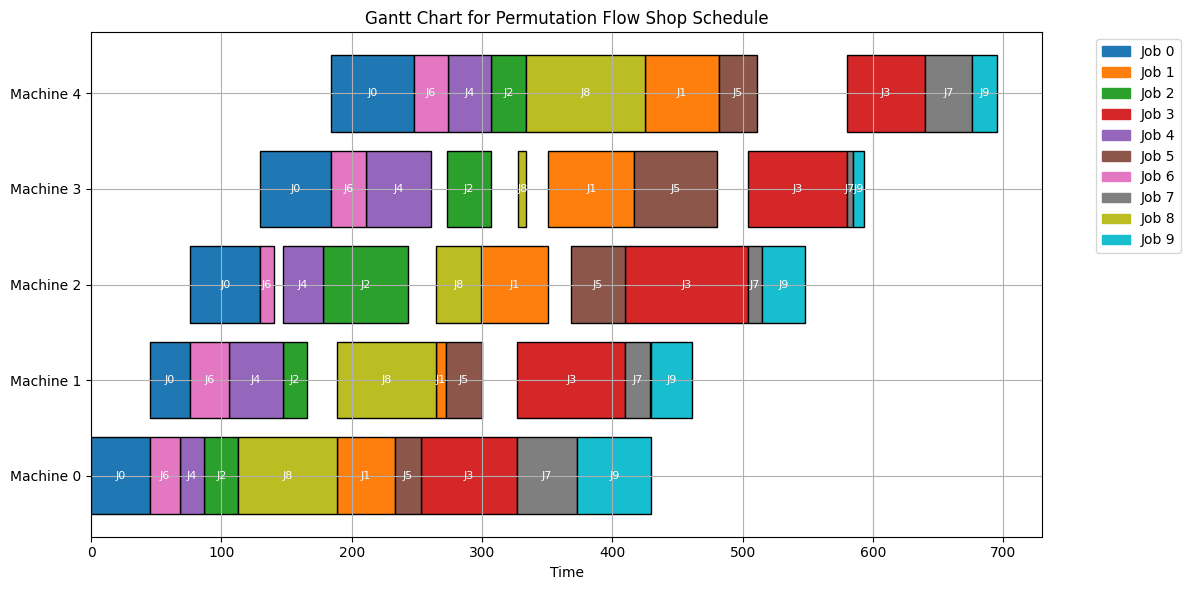

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Completion and processing times (from Gurobi output and input)
completion_times = [
    [45, 76, 130, 184, 248],
    [233, 272, 351, 417, 482],
    [113, 166, 243, 307, 334],
    [327, 410, 504, 580, 640],
    [87, 147, 178, 261, 307],
    [253, 300, 410, 480, 511],
    [68, 106, 140, 211, 274],
    [373, 429, 515, 585, 676],
    [189, 265, 299, 334, 425],
    [430, 461, 548, 593, 695],
]

processing_times = [
    [45, 31, 54, 54, 64],
    [44, 7, 52, 66, 57],
    [26, 19, 65, 34, 27],
    [74, 83, 94, 76, 60],
    [19, 41, 31, 50, 33],
    [20, 28, 42, 63, 29],
    [23, 30, 10, 27, 26],
    [46, 19, 11, 5, 36],
    [76, 76, 34, 6, 91],
    [57, 31, 33, 8, 19],
]

num_jobs = len(completion_times)
num_machines = len(completion_times[0])
colors = plt.cm.get_cmap("tab10", num_jobs)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot each job's bar on each machine
for j in range(num_jobs):
    for m in range(num_machines):
        start = completion_times[j][m] - processing_times[j][m]
        duration = processing_times[j][m]
        ax.barh(m, duration, left=start, color=colors(j), edgecolor='black')
        ax.text(start + duration / 2, m, f'J{j}', va='center', ha='center', color='white', fontsize=8)

# Axis labels and title
ax.set_yticks(range(num_machines))
ax.set_yticklabels([f"Machine {m}" for m in range(num_machines)])
ax.set_xlabel("Time")
ax.set_title("Gantt Chart for Permutation Flow Shop Schedule")
ax.grid(True)

# Job color legend
legend_handles = [mpatches.Patch(color=colors(j), label=f'Job {j}') for j in range(num_jobs)]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()